In [1]:
"""
Baseline ResNet-50 for Thoracic Disease Classification
Based on: El-Fiky et al. (2021) - Multi-Label Transfer Learning

This notebook implements the baseline ResNet-50 model using transfer learning
methodology from the paper to achieve comparable performance (AUC: 0.911, F1: 0.66)
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
warnings.filterwarnings('ignore')
import tensorflow_addons as tfa

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# CONFIGURATION - Following El-Fiky et al. (2021) Paper
# ============================================================================

# Dataset configuration
IMAGE_SIZE = 224  # Paper uses 224x224
BATCH_SIZE = 32   # Paper uses batch size 32
EPOCHS = 10      # Paper uses 60 epochs
LEARNING_RATE = 0.0005  # Paper uses 0.001
# Focal Loss hyperparameters

# Disease labels (14 diseases + No Finding)
CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'No Finding', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Number of Classes: {NUM_CLASSES}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 10
  Learning Rate: 0.0005
  Number of Classes: 15


In [3]:
# ============================================================================
# DATA LOADING
# ============================================================================

BASE_DIR = "../dataset_unbalanced/"
CSV_PATH = os.path.join(BASE_DIR, "Data_Entry_2017.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"\nLoading dataset from: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

print(f"Original dataset: {len(df):,} images")

# ============================================================================
# PARSE MULTI-LABEL FORMAT
# ============================================================================
# NIH dataset format: "Finding Labels" column with pipe-separated diseases
# Example: "Infiltration|Effusion" or "No Finding"

print("\nParsing multi-label disease annotations...")

# Check if labels already parsed or need parsing
if 'Finding Labels' in df.columns:
    # Need to parse - this is the original format
    print("Parsing 'Finding Labels' column into binary columns...")
    
    # Parse ALL 15 classes (14 diseases + No Finding)
    for class_name in CLASS_NAMES:
        df[class_name] = df['Finding Labels'].apply(
            lambda x: 1 if class_name in str(x) else 0
        )
    
    print("✓ Labels parsed successfully")
    
else:
    # Already parsed - ensure all columns exist
    print("Labels appear to be already parsed")
    for class_name in CLASS_NAMES:
        if class_name not in df.columns:
            print(f"Warning: {class_name} not found, adding as zeros")
            df[class_name] = 0

# ============================================================================
# CREATE IMAGE PATHS
# ============================================================================

def create_image_path(filename):
    return os.path.join(IMAGE_DIR, filename)

if 'Image Index' in df.columns:
    df['image_path'] = df['Image Index'].apply(create_image_path)
elif 'Path' in df.columns:
    df['image_path'] = df['Path'].apply(create_image_path)
else:
    df['image_path'] = df.iloc[:, 0].apply(create_image_path)

# ============================================================================
# VERIFY IMAGE FILES EXIST
# ============================================================================

print("\nVerifying image files exist...")
valid_indices = []
missing_count = 0

for idx, row in df.iterrows():
    if os.path.exists(row['image_path']):
        valid_indices.append(idx)
    else:
        missing_count += 1
        if missing_count <= 5:  # Show first 5 missing files
            print(f"  Missing: {row['image_path']}")

df = df.iloc[valid_indices].reset_index(drop=True)

print(f"\n✓ Valid images: {len(df):,}")
if missing_count > 0:
    print(f"Missing images: {missing_count:,}")

# ============================================================================
# CLASS DISTRIBUTION (BEFORE DOWNSAMPLING)
# ============================================================================

print("\nClass Distribution (Original Dataset):")
print("="*60)
for class_name in CLASS_NAMES:
    positive_count = int(df[class_name].sum())
    percentage = (positive_count / len(df)) * 100
    print(f"{class_name:20s}: {positive_count:6,} ({percentage:5.2f}%)")


Loading dataset from: ../dataset_unbalanced/Data_Entry_2017.csv
Original dataset: 112,120 images

Parsing multi-label disease annotations...
Parsing 'Finding Labels' column into binary columns...
✓ Labels parsed successfully

Verifying image files exist...

✓ Valid images: 112,120

Class Distribution (Original Dataset):
Atelectasis         : 11,559 (10.31%)
Cardiomegaly        :  2,776 ( 2.48%)
Consolidation       :  4,667 ( 4.16%)
Edema               :  2,303 ( 2.05%)
Effusion            : 13,317 (11.88%)
Emphysema           :  2,516 ( 2.24%)
Fibrosis            :  1,686 ( 1.50%)
Hernia              :    227 ( 0.20%)
Infiltration        : 19,894 (17.74%)
Mass                :  5,782 ( 5.16%)
Nodule              :  6,331 ( 5.65%)
No Finding          : 60,361 (53.84%)
Pleural_Thickening  :  3,385 ( 3.02%)
Pneumonia           :  1,431 ( 1.28%)
Pneumothorax        :  5,302 ( 4.73%)


In [4]:
# ============================================================================
# RANDOM DOWNSAMPLING TO 50,000 IMAGES (El-Fiky Methodology)
# ============================================================================
# Paper uses 50,000 randomly sampled images from 112,120 total
# This reduces computational cost while maintaining performance

TARGET_SAMPLES = 50000

print("\n" + "="*60)
print(f"RANDOM DOWNSAMPLING TO {TARGET_SAMPLES:,} IMAGES")
print("="*60)
print(f"Original dataset size: {len(df):,} images")

# Random sampling with fixed seed for reproducibility
df_sampled = df.sample(n=TARGET_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Sampled dataset size:  {len(df_sampled):,} images")
print(f"Sampling ratio:        {(TARGET_SAMPLES/len(df))*100:.2f}%")

# Report class distribution after sampling
print("\nClass Distribution (After Downsampling):")
print("-"*60)
for class_name in CLASS_NAMES:
    positive_count = int(df_sampled[class_name].sum())
    percentage = (positive_count / len(df_sampled)) * 100
    print(f"{class_name:20s}: {positive_count:6,} ({percentage:5.2f}%)")

# Replace original dataframe with sampled version
df = df_sampled.copy()

print("\n✓ Dataset downsampled successfully!")
print("="*60)


RANDOM DOWNSAMPLING TO 50,000 IMAGES
Original dataset size: 112,120 images
Sampled dataset size:  50,000 images
Sampling ratio:        44.60%

Class Distribution (After Downsampling):
------------------------------------------------------------
Atelectasis         :  5,118 (10.24%)
Cardiomegaly        :  1,289 ( 2.58%)
Consolidation       :  2,066 ( 4.13%)
Edema               :  1,011 ( 2.02%)
Effusion            :  5,993 (11.99%)
Emphysema           :  1,104 ( 2.21%)
Fibrosis            :    742 ( 1.48%)
Hernia              :    103 ( 0.21%)
Infiltration        :  8,812 (17.62%)
Mass                :  2,541 ( 5.08%)
Nodule              :  2,857 ( 5.71%)
No Finding          : 26,933 (53.87%)
Pleural_Thickening  :  1,488 ( 2.98%)
Pneumonia           :    645 ( 1.29%)
Pneumothorax        :  2,372 ( 4.74%)

✓ Dataset downsampled successfully!


In [5]:
# ============================================================================
# TRAIN/TEST SPLIT - Paper uses 80/20 split
# ============================================================================

print("\nSplitting dataset (80% train, 20% test)...")
train_df, val_df = train_test_split(
    df, 
    test_size=0.2,  # 80/20 split as per papers
    random_state=42,
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


Splitting dataset (80% train, 20% test)...
Training samples: 40000
Validation samples: 10000


In [6]:
# ============================================================================
# TF.DATA DATASET CREATION (No Sample Weights)
# ============================================================================

print("\n" + "="*80)
print("CREATING TF.DATA DATASETS")
print("="*80)

# Function to load and preprocess a single image
def load_and_preprocess_image(img_path, labels):
    """
    Load image from path, resize, and apply ResNet50 preprocessing.
    """
    # Read and decode image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)  # Adjust if images are JPEG: tf.image.decode_jpeg
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Apply ResNet50 preprocessing
    img = tf.keras.applications.resnet50.preprocess_input(img)
    
    return img, labels

# Create training dataset
train_ds = tf.data.Dataset.from_tensor_slices((
    train_df['image_path'].values,
    train_df[CLASS_NAMES].values.astype(np.float32)
))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000)  # Shuffle training data
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)  # Prefetch for performance

# Create validation dataset (no shuffling or augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((
    val_df['image_path'].values,
    val_df[CLASS_NAMES].values.astype(np.float32)
))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print(f"\n✓ Datasets created:")
print(f"  Training batches: {len(train_df) // BATCH_SIZE}")
print(f"  Validation batches: {len(val_df) // BATCH_SIZE}")


CREATING TF.DATA DATASETS

✓ Datasets created:
  Training batches: 1250
  Validation batches: 312


In [7]:
# ============================================================================
# MODEL ARCHITECTURE - ResNet-50 Transfer Learning (Paper Methodology)
# ============================================================================

def create_baseline_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=NUM_CLASSES
):
    """
    Create baseline ResNet-50 model following El-Fiky et al. (2021)
    
    Paper methodology:
    - Uses ResNet-50 pre-trained on ImageNet
    - Fine-tunes all layers
    - Replaces FC layer with 15 neurons (14 diseases + No Finding)
    - Uses sigmoid activation for multi-label classification
    """
    
    # Load ResNet-50 pre-trained on ImageNet
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling='avg'  # Global average pooling as per paper
    )
    
    # Make all layers trainable (fine-tuning)
    base_model.trainable = False
    
    # Build model WITHOUT training parameter
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs) 
    
    # Paper replaces FC layer with custom layer
    outputs = layers.Dense(
        num_classes, 
        activation='sigmoid',
        name='predictions'
    )(x)
    
    model = keras.Model(inputs, outputs, name='Baseline_ResNet50')
    
    return model

print("\nCreating Baseline ResNet-50 model...")
model = create_baseline_resnet50()  # ← REMOVED fine_tune parameter

print(f"\nModel Summary:")
print(f"  Total parameters: {model.count_params():,}")
print(f"  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


Creating Baseline ResNet-50 model...

Model Summary:
  Total parameters: 23,618,447
  Trainable parameters: 30,735


In [8]:
# ============================================================================
# COMPILE MODEL WITH FOCAL LOSS
# ============================================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=tfa.losses.SigmoidFocalCrossEntropy(),
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True, num_thresholds=200),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\n✓ Model compiled with Focal Loss!")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: {LEARNING_RATE}")
print("="*80)


✓ Model compiled with Focal Loss!
  Optimizer: Adam
  Learning Rate: 0.0005


In [9]:
callbacks_focal = [
    ModelCheckpoint(
        filepath='./output/SigmoidCE_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [10]:
# Train with sample weights
# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_focal,
    verbose=1
)

model.save('./output/SigmoidCE_final.keras')
print("\n✓ Training complete! Focal Loss model saved.")

Epoch 1/10
1250/1250 [==============================] - ETA: 0s - loss: 0.3526 - binary_accuracy: 0.9217 - auc: 0.6384 - precision: 0.6644 - recall: 0.1380
Epoch 1: val_auc improved from -inf to 0.71780, saving model to ./output\SigmoidCE_best.keras
1250/1250 [==============================] - 170s 122ms/step - loss: 0.3526 - binary_accuracy: 0.9217 - auc: 0.6384 - precision: 0.6644 - recall: 0.1380 - val_loss: 0.3118 - val_binary_accuracy: 0.9221 - val_auc: 0.7178 - val_precision: 0.7672 - val_recall: 0.1108 - lr: 5.0000e-04
Epoch 2/10
1250/1250 [==============================] - ETA: 0s - loss: 0.3062 - binary_accuracy: 0.9242 - auc: 0.7137 - precision: 0.7554 - recall: 0.1441
Epoch 2: val_auc improved from 0.71780 to 0.73945, saving model to ./output\SigmoidCE_best.keras
1250/1250 [==============================] - 181s 142ms/step - loss: 0.3062 - binary_accuracy: 0.9242 - auc: 0.7137 - precision: 0.7554 - recall: 0.1441 - val_loss: 0.3036 - val_binary_accuracy: 0.9252 - val_auc: 0.

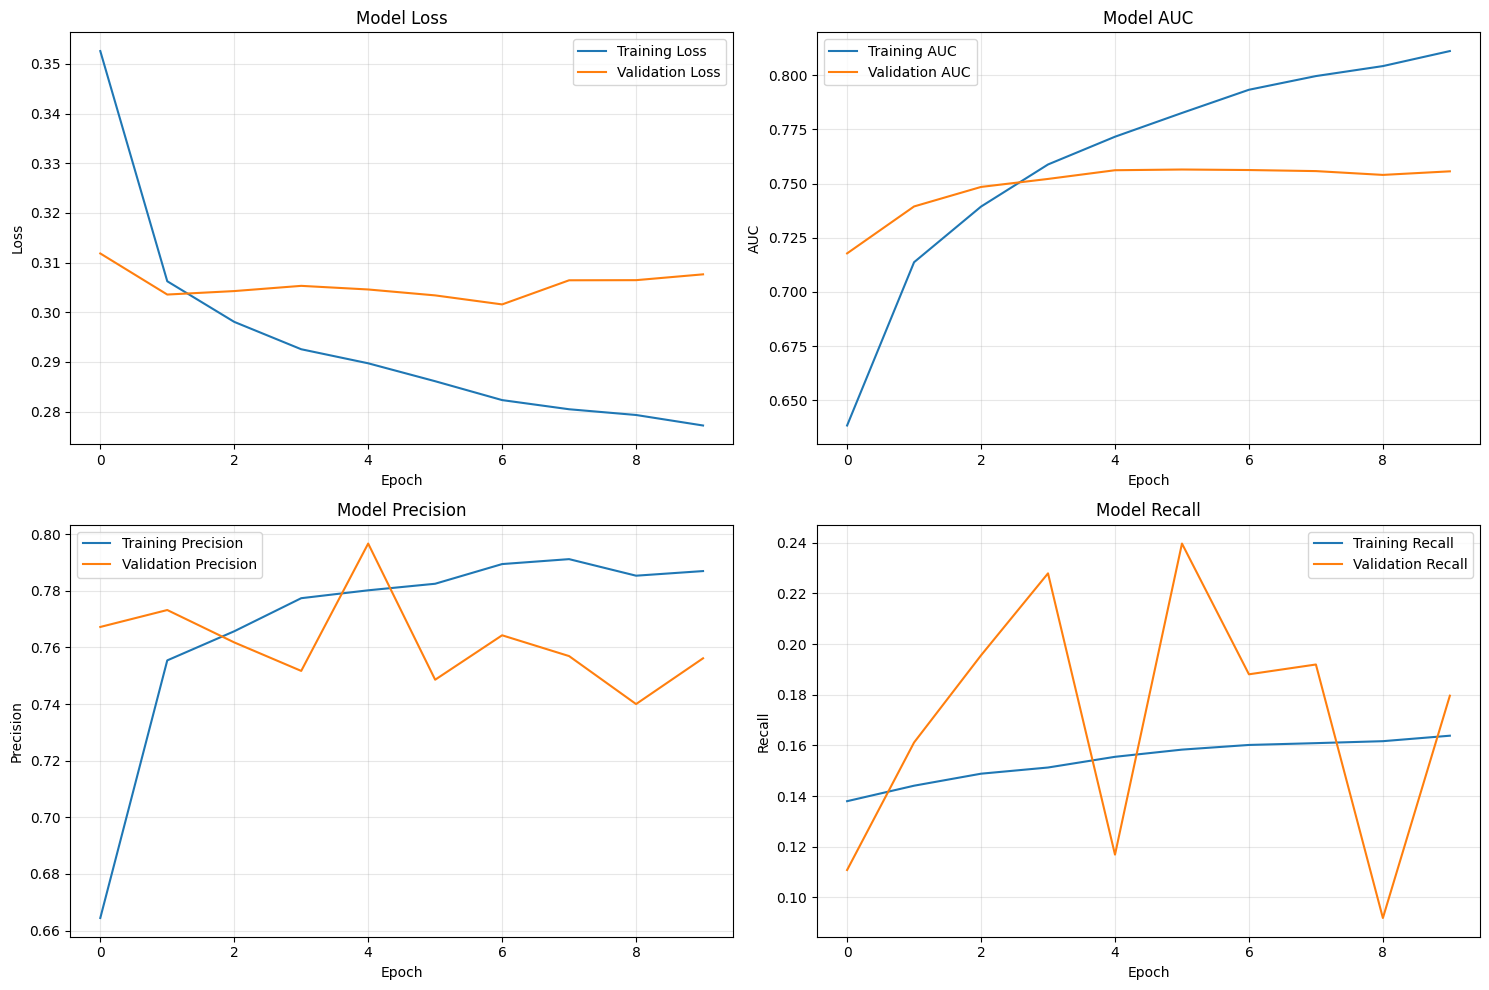

In [11]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [12]:
# ============================================================================
# COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION")
print("="*80)

# Generate predictions on validation dataset
print("Generating predictions on validation set...")
predictions = model.predict(val_ds, verbose=1)  # ← Use val_dataset

# Get true labels from validation dataframe
y_true = val_df[CLASS_NAMES].values

print(f"\nPredictions shape: {predictions.shape}")
print(f"True labels shape: {y_true.shape}")


COMPREHENSIVE EVALUATION
Generating predictions on validation set...
313/313 [==============================] - 27s 83ms/step

Predictions shape: (10000, 15)
True labels shape: (10000, 15)


In [13]:
# ============================================================================
# PER-CLASS AUC SCORES (Table 3 in Paper)
# ============================================================================

print("\n" + "="*70)
print("TABLE 3: PER-CLASS AUC SCORES (Comparison with El-Fiky et al. 2021)")
print("="*70)
print(f"{'Disease':<25s} {'Our AUC':>12s} {'Paper AUC':>12s} {'Difference':>12s}")
print("-"*70)

# Paper's reported AUC values from El-Fiky et al. (2021) Table 3
paper_aucs = {
    'Atelectasis': 0.896,
    'Cardiomegaly': 0.934,
    'Consolidation': 0.871,
    'Edema': 0.943,
    'Effusion': 0.936,
    'Emphysema': 0.941,
    'Fibrosis': 0.931,
    'Hernia': 0.873,
    'Infiltration': 0.845,
    'Mass': 0.932,
    'Nodule': 0.894,
    'Pleural_Thickening': 0.911,
    'Pneumonia': 0.915,
    'Pneumothorax': 0.934
}

per_class_aucs = []
for i, class_name in enumerate(CLASS_NAMES):
    try:
        # Check if class has both positive and negative samples
        if len(np.unique(y_true[:, i])) > 1:
            auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
            per_class_aucs.append(auc_score)
            
            paper_auc = paper_aucs.get(class_name, 0.0)
            diff = auc_score - paper_auc
            
            print(f"{class_name:<25s} {auc_score:>12.4f} {paper_auc:>12.4f} {diff:>+12.4f}")
        else:
            per_class_aucs.append(0.0)
            print(f"{class_name:<25s} {'N/A':>12s} {'N/A':>12s} {'N/A':>12s}")
    except Exception as e:
        per_class_aucs.append(0.0)
        print(f"{class_name:<25s} {'ERROR':>12s} {'ERROR':>12s} {'ERROR':>12s}")
        print(f"  Error details: {str(e)}")

# Calculate average AUC
valid_aucs = [auc for auc in per_class_aucs if auc > 0]
avg_auc = np.mean(valid_aucs) if valid_aucs else 0.0
paper_avg_auc = 0.911

print("-"*70)
print(f"{'AVERAGE AUC':<25s} {avg_auc:>12.4f} {paper_avg_auc:>12.4f} {avg_auc-paper_avg_auc:>+12.4f}")
print("="*70)

# Performance assessment
print("\nPerformance Assessment:")
if avg_auc >= 0.90:
    print("✓ EXCELLENT: Comparable to paper performance!")
    status = "success"
elif avg_auc >= 0.85:
    print("~ GOOD: Close to paper performance")
    status = "acceptable"
else:
    print("⚠ NEEDS IMPROVEMENT: Below paper performance")
    status = "needs_work"
    
print(f"  Your AUC: {avg_auc:.4f}")
print(f"  Paper AUC: {paper_avg_auc:.4f}")
print(f"  Gap: {abs(avg_auc - paper_avg_auc):.4f} ({((avg_auc - paper_avg_auc)/paper_avg_auc)*100:+.2f}%)")


TABLE 3: PER-CLASS AUC SCORES (Comparison with El-Fiky et al. 2021)
Disease                        Our AUC    Paper AUC   Difference
----------------------------------------------------------------------
Atelectasis                     0.7311       0.8960      -0.1649
Cardiomegaly                    0.8032       0.9340      -0.1308
Consolidation                   0.7327       0.8710      -0.1383
Edema                           0.8637       0.9430      -0.0793
Effusion                        0.8157       0.9360      -0.1203
Emphysema                       0.8031       0.9410      -0.1379
Fibrosis                        0.7359       0.9310      -0.1951
Hernia                          0.9322       0.8730      +0.0592
Infiltration                    0.6702       0.8450      -0.1748
Mass                            0.6896       0.9320      -0.2424
Nodule                          0.6434       0.8940      -0.2506
No Finding                      0.7324       0.0000      +0.7324
Pleural_Thicken

In [14]:
# ============================================================================
# TABLE 2: OVERALL METRICS (Micro F1-score and Hamming Loss)
# ============================================================================

# Binary predictions at 0.5 threshold (as per paper)
y_pred_binary = (predictions > 0.5).astype(int)

# Calculate metrics following paper methodology
from sklearn.metrics import f1_score, precision_score, recall_score

micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
micro_precision = precision_score(y_true, y_pred_binary, average='micro', zero_division=0)
micro_recall = recall_score(y_true, y_pred_binary, average='micro', zero_division=0)
hamming = hamming_loss(y_true, y_pred_binary)

print("\n" + "="*70)
print("TABLE 2: OVERALL PERFORMANCE METRICS (El-Fiky et al. 2021)")
print("="*70)
print(f"{'Metric':<25s} {'Our Score':>15s} {'Paper Score':>15s} {'Difference':>12s}") 
print("-"*70)
print(f"{'Average AUC':<25s} {avg_auc:>15.4f} {0.911:>15.4f} {avg_auc-0.911:>+12.4f}")
print(f"{'Micro F1-score':<25s} {micro_f1:>15.4f} {0.660:>15.4f} {micro_f1-0.660:>+12.4f}")
print(f"{'Macro F1-score':<25s} {macro_f1:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Micro Precision':<25s} {micro_precision:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Micro Recall':<25s} {micro_recall:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Hamming Loss':<25s} {hamming:>15.4f} {0.404:>15.4f} {hamming-0.404:>+12.4f}")
print("="*70)

# Performance summary
print("\nPerformance Summary:")
meets_auc = "✓" if avg_auc >= 0.90 else "✗"
meets_f1 = "✓" if micro_f1 >= 0.60 else "✗"
meets_hamming = "✓" if hamming <= 0.45 else "✗"

print(f"  {meets_auc} Average AUC:    {avg_auc:.4f} (Target: ≥0.90)")
print(f"  {meets_f1} Micro F1:       {micro_f1:.4f} (Target: ≥0.60)")
print(f"  {meets_hamming} Hamming Loss:  {hamming:.4f} (Target: ≤0.45)")


TABLE 2: OVERALL PERFORMANCE METRICS (El-Fiky et al. 2021)
Metric                          Our Score     Paper Score   Difference
----------------------------------------------------------------------
Average AUC                        0.7558          0.9110      -0.1552
Micro F1-score                     0.2903          0.6600      -0.3697
Macro F1-score                     0.0588             N/A          N/A
Micro Precision                    0.7561             N/A          N/A
Micro Recall                       0.1797             N/A          N/A
Hamming Loss                       0.0742          0.4040      -0.3298

Performance Summary:
  ✗ Average AUC:    0.7558 (Target: ≥0.90)
  ✗ Micro F1:       0.2903 (Target: ≥0.60)
  ✓ Hamming Loss:  0.0742 (Target: ≤0.45)


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORT
# ============================================================================

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_true, 
    y_pred_binary, 
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=4
))


DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

       Atelectasis     0.0000    0.0000    0.0000      1044
      Cardiomegaly     0.3265    0.0645    0.1077       248
     Consolidation     0.0000    0.0000    0.0000       416
             Edema     0.0000    0.0000    0.0000       226
          Effusion     0.6220    0.0826    0.1458      1235
         Emphysema     0.2667    0.0203    0.0377       197
          Fibrosis     0.0000    0.0000    0.0000       163
            Hernia     0.0000    0.0000    0.0000        12
      Infiltration     0.4677    0.0160    0.0309      1817
              Mass     0.0000    0.0000    0.0000       490
            Nodule     0.4000    0.0037    0.0074       535
        No Finding     0.7832    0.3937    0.5240      5377
Pleural_Thickening     0.5000    0.0035    0.0070       283
         Pneumonia     0.0000    0.0000    0.0000       160
      Pneumothorax     0.6250    0.0107    0.0211       466

      

: 